In [1]:
import pandas as pd

df = pd.read_csv("data/raw/imdb_train.csv")
df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [2]:
df["label"].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [3]:
df["char_len"] = df["text"].str.len()
df["word_len"] = df["text"].str.split().str.len()

df[["char_len", "word_len"]].describe()

,char_len,word_len
count,25000.00000,25000.000000
mean,1325.06964,233.787200
std,1003.13367,173.733032
min,52.00000,10.000000
25%,702.00000,127.000000
50%,979.00000,174.000000
75%,1614.00000,284.000000
max,13704.00000,2470.000000


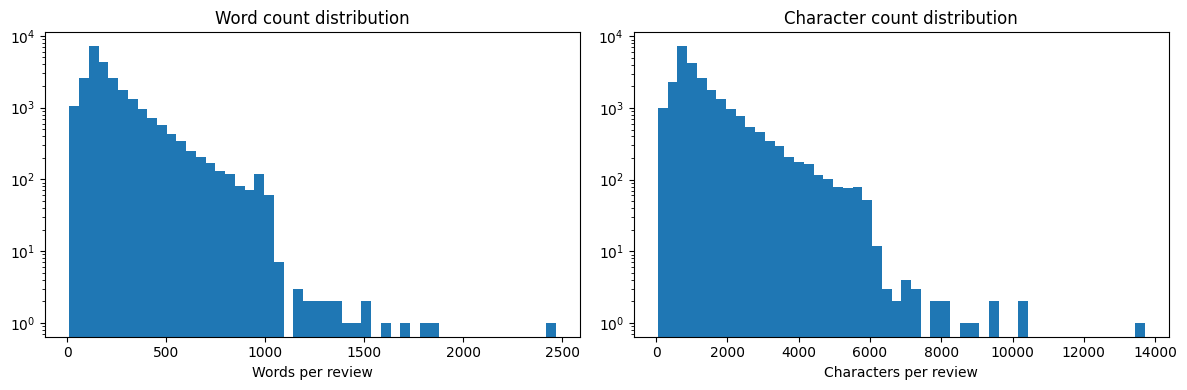

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["word_len"], bins=50)
axes[0].set_yscale("log")
axes[0].set_title("Word count distribution")
axes[0].set_xlabel("Words per review")

axes[1].hist(df["char_len"], bins=50)
axes[1].set_yscale("log")
axes[1].set_title("Character count distribution")
axes[1].set_xlabel("Characters per review")

plt.tight_layout()
plt.show()

In [5]:
import sys
sys.path.append("../src")
from preprocess_nltk import clean_text
from collections import Counter

df["clean_text"] = df["text"].apply(clean_text)

pos_words = " ".join(df.loc[df["label"] == 1, "clean_text"]).split()
neg_words = " ".join(df.loc[df["label"] == 0, "clean_text"]).split()

print("Top 20 words — positive reviews:")
print(Counter(pos_words).most_common(20))

print("\nTop 20 words — negative reviews:")
print(Counter(neg_words).most_common(20))

Top 20 words — positive reviews:
[('film', 23858), ('movie', 21785), ('one', 13506), ('like', 8916), ('time', 7747), ('good', 7408), ('story', 7186), ('character', 6864), ('great', 6271), ('see', 6170), ('get', 5717), ('well', 5567), ('make', 5559), ('really', 5437), ('also', 5421), ('would', 5285), ('even', 4820), ('scene', 4817), ('show', 4745), ('life', 4706)]

Top 20 words — negative reviews:
[('movie', 27794), ('film', 21329), ('one', 12806), ('like', 11108), ('even', 7505), ('good', 7154), ('time', 7125), ('bad', 7064), ('character', 6930), ('would', 6839), ('get', 6696), ('make', 6343), ('really', 6202), ('see', 5545), ('story', 5435), ('scene', 5411), ('dont', 5041), ('much', 4969), ('people', 4737), ('thing', 4573)]


In [6]:
from sklearn.feature_extraction.text import CountVectorizer

def top_bigrams(texts, n=20):
    vec = CountVectorizer(ngram_range=(2, 2))
    X = vec.fit_transform(texts)
    counts = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    return sorted(zip(vocab, counts), key=lambda x: -x[1])[:n]

print("Top 20 bigrams — positive reviews:")
print(top_bigrams(df.loc[df["label"] == 1, "clean_text"]))

print("\nTop 20 bigrams — negative reviews:")
print(top_bigrams(df.loc[df["label"] == 0, "clean_text"]))

Top 20 bigrams — positive reviews:
[('one best', 759), ('even though', 535), ('ive seen', 520), ('first time', 477), ('new york', 466), ('ever seen', 460), ('dont know', 445), ('special effect', 416), ('year old', 404), ('year ago', 384), ('look like', 382), ('see movie', 381), ('movie like', 374), ('main character', 363), ('good movie', 352), ('great movie', 345), ('watch movie', 309), ('film like', 307), ('well done', 301), ('horror film', 295)]

Top 20 bigrams — negative reviews:
[('look like', 1046), ('ever seen', 771), ('waste time', 703), ('special effect', 670), ('ive seen', 577), ('bad movie', 575), ('worst movie', 575), ('dont know', 571), ('main character', 553), ('movie ever', 525), ('movie like', 508), ('horror movie', 498), ('one worst', 472), ('much better', 471), ('year old', 461), ('even though', 436), ('ive ever', 416), ('make movie', 416), ('low budget', 402), ('horror film', 401)]


In [7]:
dupes = df.duplicated(subset="text").sum()
print(f"Duplicate reviews found: {dupes}")

df = df.drop_duplicates(subset="text").reset_index(drop=True)
print(f"Rows after dedup: {len(df)}")

Duplicate reviews found: 96
Rows after dedup: 24904


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

df_test = pd.read_csv("data/raw/imdb_test.csv")

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95)),
    ("clf", LogisticRegression(max_iter=1000, n_jobs=-1)),
])

pipe.fit(df["text"], df["label"])

preds = pipe.predict(df_test["text"])

print("Accuracy:", accuracy_score(df_test["label"], preds))
print("F1:", f1_score(df_test["label"], preds))
print()
print(classification_report(df_test["label"], preds))

Accuracy: 0.89004
F1: 0.8907175511826675

              precision    recall  f1-score   support

           0       0.89      0.88      0.89     12500
           1       0.89      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



In [9]:
import os
import joblib

os.makedirs("models", exist_ok=True)
joblib.dump(pipe, "models/day02_baseline.joblib")
print("Saved.")

Saved.


In [1]:
import sqlite3, pandas as pd

df = pd.read_csv("data/raw/imdb_train.csv").sample(1000, random_state=42)
df["sentiment"] = df["label"].map({0: "negative", 1: "positive"})

con = sqlite3.connect("reviews.db")
df.to_sql("reviews", con, if_exists="replace", index=False)

# Query it back
pd.read_sql("SELECT sentiment, COUNT(*) AS n FROM reviews GROUP BY sentiment;", con)

,sentiment,n
0,negative,511
1,positive,489
